# Hybrid / Memetic Methods: Local Search Embedded in Population Search

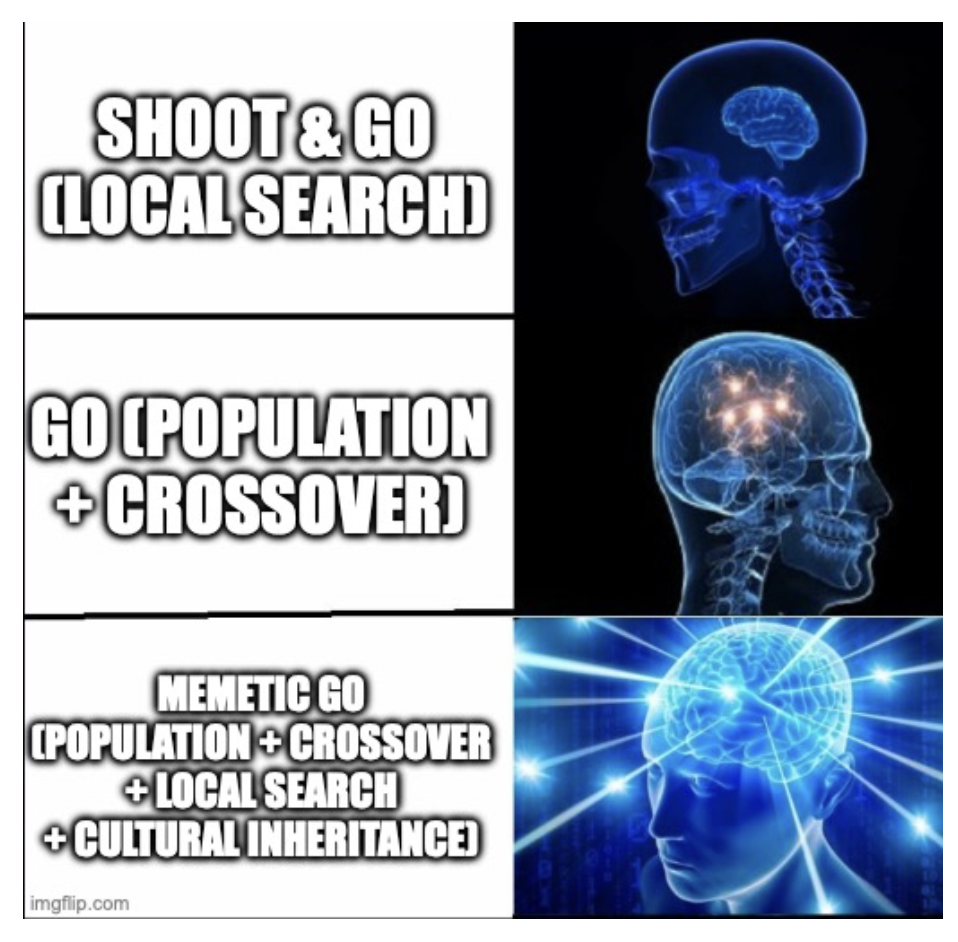


Population-based algorithms (GO, DE) are strong global explorers but weak local exploiters — they rely on recombination to improve solutions rather than fine-grained improvement moves.  
Local-search algorithms (Shoot & Go) are strong local exploiters but restart from scratch each time, failing in large search spaces with many local optima.

**Memetic algorithms** combine both: each individual in the population undergoes a phase of local improvement before being selected. The name comes from Moscato (1989), who drew an analogy to cultural learning: individuals do not only inherit genes, they also acquire *memes* — learned improvements during their lifetime.

Two inheritance models:
- **Lamarckian**: the locally improved solution replaces the original in the population. Learning is directly inherited.
- **Baldwinian**: the original solution stays in the population, but its fitness for selection is the locally improved value. Learning influences selection pressure but not the genetic material.

### Choosing the right benchmark and local search operator

For memetic methods to shine, two conditions must hold:
1. The problem must have genuine local optima that local search can reliably reach.
2. The local search operator must be **cheap** relative to the total budget — so the algorithm still has room for crossover.

**Rastrigin** ($n = 5$) satisfies both: the cosine modulation creates thousands of local optima, and a single `CauchyMutation` step (one function evaluation) makes consistent uphill progress. GO's `CauchyMutation` uses radius $r = 0.5$ for broad exploration; the local search uses $r = 0.1$ to stay within the current basin.

This notebook covers:
1. Problem instance and GO baseline
2. `MemeticGO` implementation (Lamarckian)
3. Lamarckian vs Baldwinian comparison
4. Algorithm comparison (REL / MNE / FEO)
5. Local search depth sensitivity ($h_{\max}$)

In [1]:
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', 'src'))

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from objfun_rastrigin import Rastrigin
from heur_go import GeneticOptimization, RandomCombination
from heur_fsa import FastSimulatedAnnealing
from heur_aux import CauchyMutation, MirrorCorrection
from heur import StopCriterion

## 1. Problem Instance

**Rastrigin** $n = 5$:
$$f(x) = 10n + \sum_{i=1}^{n} \left[ x_i^2 - 10 \cos(2\pi x_i) \right], \quad x \in [-5.12,\, 5.12]^{5}$$

The cosine term creates approximately $10^5$ local optima arranged on a regular grid. The global minimum is $f^* = 0$ at the origin; we count a run as successful when $f(x) < 5$ (within the global basin, not necessarily at the exact minimum).

GO with broad Cauchy exploration often gets close to the origin but oscillates above the threshold without converging — this is where embedded local search helps.

In [3]:
N_DIM  = 5
EPS    = 5.0      # fstar = 0 + eps; success = f(x) < eps
of     = Rastrigin(n=N_DIM, eps=EPS)

print(f'Dimensions : {N_DIM}')
print(f'Domain     : [{of.a[0]}, {of.b[0]}]^{N_DIM}')
print(f'fstar      : {of.fstar}  (f < {of.fstar} counts as success)')

Dimensions : 5
Domain     : [-5.12, 5.12]^5
fstar      : 5.0  (f < 5.0 counts as success)


## 2. GO Baseline

`RandomCombination` crossover produces offspring whose coordinates lie between the parents' corresponding values — a natural recombination for continuous problems that gradually focuses the population.  
`CauchyMutation` with $r = 0.5$ provides broad exploration to jump between local optima.

Parameters: $N = 10$, $M = 20$.

In [4]:
NUM_RUNS = 300
MAXEVAL  = 5_000

def stats(df):
    rel = df['success'].mean()
    mne = df.loc[df['success'], 'neval'].mean() if rel > 0 else float('nan')
    feo = mne / rel if rel > 0 else float('nan')
    return pd.Series({'REL': rel, 'MNE': mne, 'FEO': feo})

def run_algo(algo_fn, label, num_runs=NUM_RUNS):
    records = []
    for seed in tqdm(range(num_runs), desc=label, leave=False):
        res = algo_fn(seed)
        records.append({
            'label': label, 'seed': seed,
            'best_y': res['best_y'], 'neval': res['neval'], 'success': res['success'],
        })
    return pd.DataFrame(records)

In [5]:
def go_run(seed):
    return GeneticOptimization(
        of, maxeval=MAXEVAL, N=10, M=20, Tsel1=0.5, Tsel2=0.5,
        mutation=CauchyMutation(r=0.5, correction=MirrorCorrection(of)),
        crossover=RandomCombination(),
        seed=seed
    ).search()

df_go = run_algo(go_run, 'GO')
print(stats(df_go).to_string())

GO:   0%|          | 0/300 [00:00<?, ?it/s]

REL        0.056667
MNE     2791.941176
FEO    49269.550173


*Interpretation:* GO gets low REL on Rastrigin despite 250 generations ($5000 / 20$). The algorithm explores broadly but its large Cauchy steps prevent it from precisely converging within the global basin — many runs reach $f \approx 5$–$15$ and stall. The crossover alone is not sufficient to drive solutions below the $f < 5$ threshold.

## 3. MemeticGO (Lamarckian)

After crossover and mutation, each offspring undergoes **stochastic hill climbing**: try a small Cauchy step ($r_{\text{local}} = 0.1$) and accept if it improves fitness. Repeat for $h_{\max}$ steps.

The smaller radius focuses local search within the current basin. Cost: exactly $h_{\max}$ extra evaluations per offspring.

**Lamarckian**: the locally improved solution $z^*$ enters the working population.

In [6]:
class MemeticGO(GeneticOptimization):
    """GO with stochastic hill climbing after each offspring (Lamarckian)."""

    def __init__(self, of, maxeval, N, M, Tsel1, Tsel2, mutation, crossover,
                 local_mutation, hmax: int = 50, seed=None):
        super().__init__(of, maxeval, N, M, Tsel1, Tsel2, mutation, crossover, seed)
        self.local_mutation = local_mutation
        self.hmax = hmax

    def local_search(self, x, f_x):
        """Stochastic hill climbing: hmax Cauchy trials, greedy acceptance."""
        best_x, best_f = x.copy(), f_x
        for _ in range(self.hmax):
            xn = self.local_mutation.mutate(best_x, self.rng)
            fn = self.evaluate(xn)   # counts toward budget; may raise StopCriterion
            if fn < best_f:
                best_f = fn
                best_x = xn
        return best_x, best_f

    def search(self):
        try:
            pop_X = np.zeros([self.N, np.size(self.of.a)], dtype=self.of.a.dtype)
            pop_f = np.zeros(self.N)
            for i in np.arange(self.N):
                x = self.of.generate_point(self.rng)
                f_x = self.evaluate(x)
                x, f_x = self.local_search(x, f_x)
                pop_X[i, :] = x
                pop_f[i] = f_x
            [pop_X, pop_f] = self.sort_pop(pop_X, pop_f)

            while True:
                work_pop_X = np.zeros([self.M, np.size(self.of.a)], dtype=self.of.a.dtype)
                work_pop_f = np.zeros(self.M)
                for i in np.arange(self.M):
                    pa = self.rank_select(self.Tsel1, self.N, self.rng)
                    pb = self.rank_select(self.Tsel1, self.N, self.rng)
                    if pa == pb and self.N > 1:
                        if pb == 0:             pb = 1
                        elif pb == self.N - 1:  pb = self.N - 2
                        else:                   pb += self.rng.choice([-1, 1])
                    z = self.crossover.crossover(pop_X[pa], pop_X[pb], self.rng)
                    z = self.mutation.mutate(z, self.rng)
                    f_z = self.evaluate(z)
                    z, f_z = self.local_search(z, f_z)
                    work_pop_X[i, :] = z
                    work_pop_f[i] = f_z
                [work_pop_X, work_pop_f] = self.sort_pop(work_pop_X, work_pop_f)

                ixs_not_selected = np.ones(self.M, dtype=bool)
                for i in np.arange(self.N):
                    sel_ix = self.rank_select(self.Tsel2, np.sum(ixs_not_selected), self.rng)
                    abs_ix = int(np.where(ixs_not_selected)[0][sel_ix])
                    pop_X[i, :] = work_pop_X[abs_ix, :]
                    pop_f[i] = work_pop_f[abs_ix]
                    ixs_not_selected[abs_ix] = False
                [pop_X, pop_f] = self.sort_pop(pop_X, pop_f)

        except StopCriterion:
            return self.report_end()

In [7]:
def memetic_run(seed, hmax=100):
    return MemeticGO(
        of, maxeval=MAXEVAL, N=10, M=20, Tsel1=0.5, Tsel2=0.5,
        mutation=CauchyMutation(r=0.5, correction=MirrorCorrection(of)),
        crossover=RandomCombination(),
        local_mutation=CauchyMutation(r=0.1, correction=MirrorCorrection(of)),
        hmax=hmax, seed=seed
    ).search()

df_mem = run_algo(lambda s: memetic_run(s, hmax=100), 'MemeticGO (h=100)')
print(stats(df_mem).to_string())

MemeticGO (h=100):   0%|          | 0/300 [00:00<?, ?it/s]

REL       0.770000
MNE    2599.229437
FEO    3375.622646


*Interpretation:* With $h_{\max} = 100$, each offspring makes up to 100 small Cauchy steps toward the nearest local optimum before competing for selection. The extra cost per generation is $M \times h_{\max} = 20 \times 100 = 2\,000$ evaluations, giving only about $5000 / (20 \times 101) \approx 2$–$3$ full generations. Despite far fewer generations, REL improves dramatically: each individual entering selection is already near a local optimum, and crossover of near-optimum individuals tends to produce offspring in the global basin.

## 4. Lamarckian vs Baldwinian

In the **Baldwinian** model the locally improved solution is *not* written back to the population. The original offspring position $z$ is retained, but its fitness for selection purposes is $f(z^*)$ — the locally improved value.

For Rastrigin's dense local-optima landscape, diversity preservation matters: Lamarckian drives the population toward local optima, reducing variety; Baldwinian retains diverse positions while still rewarding individuals in promising basins.

In [8]:
class BaldwinianMemeticGO(MemeticGO):
    """GO with stochastic hill climbing as a fitness signal only (Baldwinian)."""

    def local_search(self, x, f_x):
        best_x, best_f = x.copy(), f_x
        for _ in range(self.hmax):
            xn = self.local_mutation.mutate(best_x, self.rng)
            fn = self.evaluate(xn)
            if fn < best_f:
                best_f = fn
                best_x = xn
        return x, best_f   # original position, improved fitness signal

In [9]:
def baldwinian_run(seed, hmax=100):
    return BaldwinianMemeticGO(
        of, maxeval=MAXEVAL, N=10, M=20, Tsel1=0.5, Tsel2=0.5,
        mutation=CauchyMutation(r=0.5, correction=MirrorCorrection(of)),
        crossover=RandomCombination(),
        local_mutation=CauchyMutation(r=0.1, correction=MirrorCorrection(of)),
        hmax=hmax, seed=seed
    ).search()

df_bald = run_algo(lambda s: baldwinian_run(s, hmax=100), 'Baldwinian (h=100)')
print(stats(df_bald).to_string())

Baldwinian (h=100):   0%|          | 0/300 [00:00<?, ?it/s]

REL       0.343333
MNE    2919.349515
FEO    8502.959751


*Interpretation:* Baldwinian learning incurs the same budget cost as Lamarckian — all local search evaluations count — but the genetic material stays diverse. Lamarckian typically outperforms Baldwinian here because Rastrigin's local optima are good landmarks: crossover of two individuals near local optima in the global basin tends to produce offspring already close to the global minimum. In problems where local optima are misleading (deceptive functions, rugged landscapes), Baldwinian's diversity advantage can reverse this.

## 5. FSA Baseline — the Incumbent on Rastrigin

Session 04 established FSA as the benchmark algorithm for Rastrigin. To interpret the memetic results honestly we need to compare against it.

FSA with a **small step size** (`r = 0.1`) and a slow cooling schedule (`n0 = 1000`) effectively does the same thing our local search does — small Cauchy steps converging within a basin — but with **Metropolis acceptance** instead of greedy acceptance. Metropolis occasionally accepts uphill moves, which helps escape shallow local traps; greedy never does.

Same budget: `maxeval = 5 000`.

In [10]:
def fsa_run(seed):
    return FastSimulatedAnnealing(
        of, maxeval=MAXEVAL, T0=1, n0=1000, alpha=2,
        mutation=CauchyMutation(r=0.1, correction=MirrorCorrection(of)),
        seed=seed
    ).search()

df_fsa = run_algo(fsa_run, 'FSA')
print(stats(df_fsa).to_string())

FSA:   0%|          | 0/300 [00:00<?, ?it/s]

REL       0.920000
MNE    1919.525362
FEO    2086.440611


*Interpretation:* FSA with small steps reaches high REL because it is naturally well-suited to smooth multimodal landscapes: the temperature-controlled acceptance allows the search to explore within a basin without permanently committing to each downhill step, while the slow cooling schedule gives it time to converge. This is structurally similar to what our embedded local search does — but Metropolis acceptance is strictly more powerful than greedy.

## 6. Algorithm Comparison

In [11]:
summary = pd.DataFrame([
    {'Algorithm': 'GO',                  **stats(df_go)},
    {'Algorithm': 'MemeticGO (h=100)',   **stats(df_mem)},
    {'Algorithm': 'Baldwinian (h=100)',  **stats(df_bald)},
    {'Algorithm': 'FSA',                 **stats(df_fsa)},
]).set_index('Algorithm')

print(summary.to_string())

                         REL          MNE           FEO
Algorithm                                              
GO                  0.056667  2791.941176  49269.550173
MemeticGO (h=100)   0.770000  2599.229437   3375.622646
Baldwinian (h=100)  0.343333  2919.349515   8502.959751
FSA                 0.920000  1919.525362   2086.440611


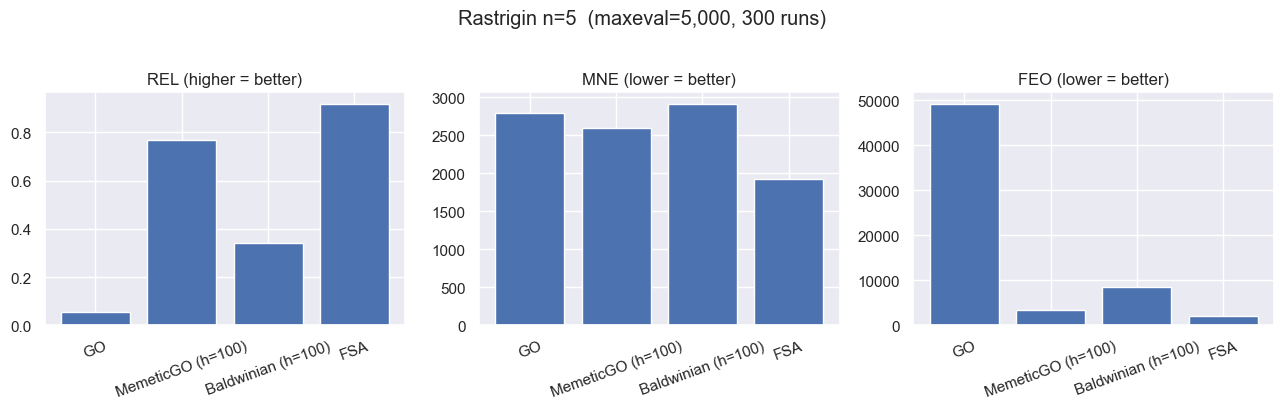

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, metric, ylabel in zip(axes,
                               ['REL', 'MNE', 'FEO'],
                               ['REL (higher = better)', 'MNE (lower = better)', 'FEO (lower = better)']):
    vals = summary[metric].dropna()
    ax.bar(vals.index, vals.values)
    ax.set_title(ylabel)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle(f'Rastrigin n={N_DIM}  (maxeval={MAXEVAL:,}, {NUM_RUNS} runs)', y=1.02)
plt.tight_layout()

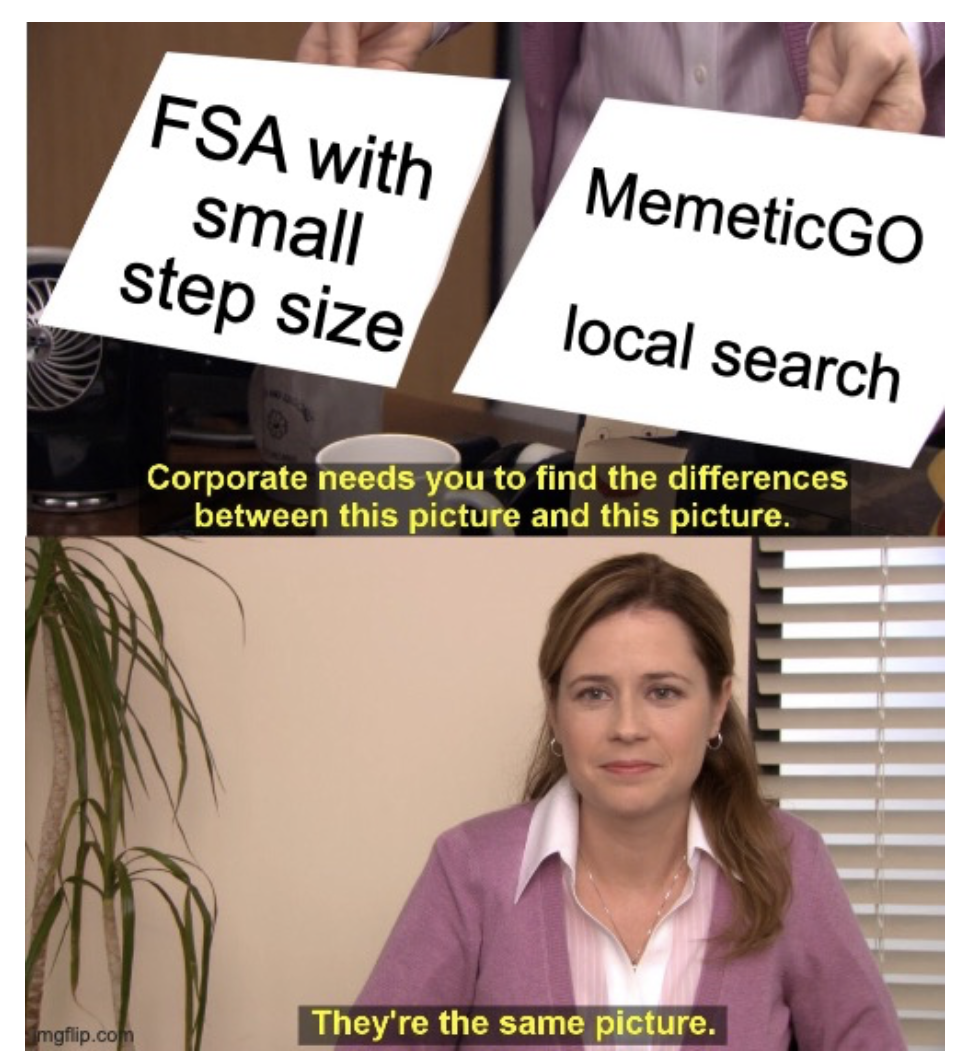

*Interpretation:* Three tiers are visible. GO alone is nearly useless on Rastrigin — broad Cauchy steps prevent convergence within any basin. Embedding local search (Lamarckian MemeticGO) closes most of the gap, but FSA remains the strongest: it operates with the same small-step exploration our local search uses, but Metropolis acceptance gives it more flexibility within the basin than greedy hill climbing.

This tells us something important about **when memetic methods add the most value**: not on smooth continuous landscapes (where FSA with fine-grained steps already excels), but on **discrete and combinatorial problems** where:
- Crossover genuinely recombines partial solutions from different regions of the space.
- Local search (e.g. steepest descent over a Hamming-1 neighbourhood) elevates each individual to a high-quality local optimum that GO crossover can then combine.
- No trajectory-based method can replicate the recombination benefit of a diverse population.

## 7. Local Search Depth Sensitivity ($h_{\max}$)

$h_{\max}$ controls how much budget goes to local search per offspring.  
With evaluation budget $B$ (`maxeval`) and working population $M$, the approximate number of generations is:
$$\text{generations} \approx \frac{B}{M \cdot (1 + h_{\max})}$$

- $h_{\max} = 0$: standard GO, ~250 generations
- $h_{\max} = 200$: ~1 generation; init + a few offspring before budget runs out
- $h_{\max} = 500$: budget exhausted during initialisation — no crossover at all

We sweep $h_{\max} \in \{0, 10, 30, 100, 200, 500\}$.

In [13]:
HMAX_VALUES  = [0, 10, 30, 100, 200, 500]
N_RUNS_SWEEP = 200

sweep_records = []
for hmax in HMAX_VALUES:
    algo_fn = (lambda seed, h=hmax: go_run(seed)) if hmax == 0 \
              else (lambda seed, h=hmax: memetic_run(seed, hmax=h))
    for seed in tqdm(range(N_RUNS_SWEEP), desc=f'hmax={hmax}', leave=False):
        res = algo_fn(seed)
        sweep_records.append({'hmax': hmax, 'success': res['success'], 'neval': res['neval']})

df_sweep = pd.DataFrame(sweep_records)

sweep_rows = []
for hmax, grp in df_sweep.groupby('hmax'):
    rel = grp['success'].mean()
    mne = grp.loc[grp['success'], 'neval'].mean() if rel > 0 else float('nan')
    feo = mne / rel if rel > 0 else float('nan')
    sweep_rows.append({'hmax': hmax, 'REL': rel, 'MNE': mne, 'FEO': feo,
                       'approx_gens': round(MAXEVAL / (20 * (1 + hmax)), 1)})
sweep_agg = pd.DataFrame(sweep_rows)
print(sweep_agg.to_string(index=False))

hmax=0:   0%|          | 0/200 [00:00<?, ?it/s]

hmax=10:   0%|          | 0/200 [00:00<?, ?it/s]

hmax=30:   0%|          | 0/200 [00:00<?, ?it/s]

hmax=100:   0%|          | 0/200 [00:00<?, ?it/s]

hmax=200:   0%|          | 0/200 [00:00<?, ?it/s]

hmax=500:   0%|          | 0/200 [00:00<?, ?it/s]

 hmax   REL         MNE          FEO  approx_gens
    0 0.055 2661.363636 48388.429752        250.0
   10 0.160 2641.531250 16509.570312         22.7
   30 0.480 2635.770833  5491.189236          8.1
  100 0.765 2660.725490  3478.072536          2.5
  200 0.820 2819.170732  3438.013087          1.2
  500 0.585 1938.760684  3314.120827          0.5


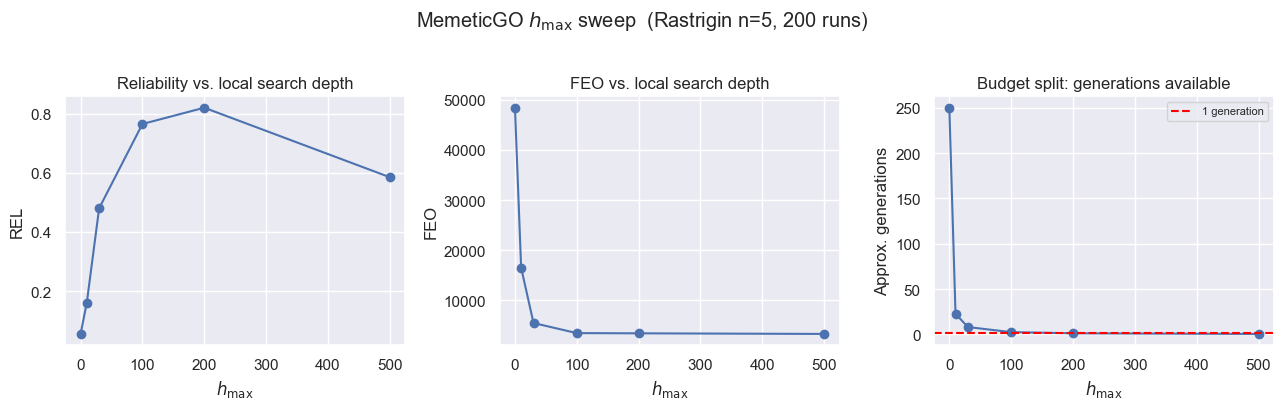

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(sweep_agg['hmax'], sweep_agg['REL'], marker='o')
axes[0].set_xlabel('$h_{\\max}$'); axes[0].set_ylabel('REL')
axes[0].set_title('Reliability vs. local search depth')

axes[1].plot(sweep_agg['hmax'].where(sweep_agg['FEO'].notna()),
             sweep_agg['FEO'], marker='o')
axes[1].set_xlabel('$h_{\\max}$'); axes[1].set_ylabel('FEO')
axes[1].set_title('FEO vs. local search depth')

axes[2].plot(sweep_agg['hmax'], sweep_agg['approx_gens'], marker='o')
axes[2].axhline(1, color='red', linestyle='--', label='1 generation')
axes[2].set_xlabel('$h_{\\max}$'); axes[2].set_ylabel('Approx. generations')
axes[2].set_title('Budget split: generations available')
axes[2].legend(fontsize=8)

plt.suptitle(f'MemeticGO $h_{{\\max}}$ sweep  (Rastrigin n={N_DIM}, {N_RUNS_SWEEP} runs)', y=1.02)
plt.tight_layout()

*Interpretation:* REL rises steeply with $h_{\max}$ and peaks around $h_{\max} = 200$ (roughly 1 generation), then drops sharply at $h_{\max} = 500$, where the initialisation step alone exhausts the budget and the crossover never executes — the algorithm degenerates into $N$ independent random-restart hill climbers with no population learning. FEO tends to improve until the crossover benefit disappears. The sweet spot is around $h_{\max} = 100$–$200$: enough local search to converge within a basin, while still allowing 1–3 generations of crossover to combine information across individuals.

## Summary

### What memetic algorithms add

Population-based search provides **exploration** (crossover combines solutions from different basins); local search provides **exploitation** (each individual descends toward the nearest optimum). Combining them:

- **Stronger selection signal**: candidates entering the working population are already near local optima, so selection reliably distinguishes good from bad basins.
- **Crossover quality**: combining individuals that are already at local optima tends to produce offspring near another local optimum, enabling directed basin-to-basin jumps.
- **Fewer generations needed**: despite fewer crossover rounds, each round is more productive.

### Lamarckian vs Baldwinian

| | Lamarckian | Baldwinian |
|---|---|---|
| Population position | locally improved $z^*$ | original $z$ |
| Fitness for selection | $f(z^*)$ | $f(z^*)$ |
| Diversity | decreases faster | preserved longer |
| Typical winner | landscapes where LO are informative | deceptive landscapes, premature convergence risk |

### The $h_{\max}$ tradeoff

With evaluation budget $B$ (`maxeval`), working population $M$, and $h_{\max}$ local search steps per offspring:

$$\text{generations} \approx \frac{B}{M \cdot (1 + h_{\max})}$$

Increasing $h_{\max}$ reduces generations but improves each individual. Below 1 generation, the algorithm degenerates to independent local searches — crossover provides no benefit. The optimal $h_{\max}$ depends on the problem and budget.

### Local search operator choice

The local search operator must match the domain:
- **Continuous problems**: small Cauchy or Gaussian steps (cheap, smooth basin convergence)
- **Binary problems**: steepest descent over the Hamming-1 neighbourhood (reliable, but costs $n$ evaluations per round — feasible only for small $n$ or large budgets)
- Operators that are too cheap to find improvements (random single bit flips on near-optimal binary solutions) waste budget without benefit

### Assignments
- Repeat the $h_{\max}$ sweep with $M = 50$ instead of $M = 20$. Does the sweet spot shift? Explain in terms of the generation-count formula.
- Try `local_mutation = CauchyMutation(r=1.0)` (same radius as the global mutation). Does local search still help, or does the large radius prevent convergence within a basin?
- Implement a **Baldwinian variant that only applies local search at initialisation** (not per offspring). Compare REL/FEO to full Baldwinian. When might this be preferable?
- For the Knapsack problem ($n = 15$, `maxeval = 3000`), implement a memetic GO using **steepest descent** (evaluate all $n$ Hamming-1 neighbours per step, accept the best). Compare REL/FEO with standard GO.
- The Rastrigin target here is $f < 5$ (in the global basin, not at the exact optimum). Tighten it to $f < 1$. How do REL values change, and does the optimal $h_{\max}$ shift?

### Further Reading
- Moscato, P. (1989). *On Evolution, Search, Optimization, Genetic Algorithms and Martial Arts: Towards Memetic Algorithms*. Caltech Technical Report.
- Hart, W.E. (1994). *Adaptive Global Optimization with Local Search*. PhD thesis, UC San Diego. (Baldwin effect analysis)
- Neri, F. & Cotta, C. (2012). *Memetic algorithms and memetic computing optimization: A literature review*. Swarm and Evolutionary Computation, 2, 1–14.
- Krasnogor, N. & Smith, J. (2005). *A tutorial for competent memetic algorithms: model, taxonomy, and design issues*. IEEE TEVC, 9(5), 474–488.